In [1]:
# Alex Medina
# AST 5765 
# Final Project
# 8 November 2025

In [2]:
# Imports
import os
import disk as d
import numpy as np
import gaussian as g
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import final_amedinasupport as sup
from astropy.stats import sigma_clip

In [3]:
print('Problem 1) \n')
print('Completed on log. \n')

Problem 1) 

Completed on log. 



In [4]:
print('Problem 2) \n')
print('Completed on log. \n')

Problem 2) 

Completed on log. 



In [5]:
print('Problem 3 \n')

Problem 3 



In [6]:
# Directory variables
datadir   = 'data/'
fext      = '.fits'

datafiles = []
for filename in os.listdir(datadir):
    if filename.startswith('SPITZER'):
        file =filename.split(fext)[0]
        datafiles.append(file)

datafiles = sorted(datafiles) # filenames
nfiles    = len(datafiles)    # number of files


# Array varriables
setn_col  = 0   # number of SPITZER file
locf_col  = 1   # local frame number (within SPITZER file)
glof_col  = 2   # global frame number (over all files)
date_col  = 3   # mid-time of the frame (MJD in days)
mbkg_col  = 4   # median background value
ycen_col  = 5   # fitted y center coordinate
xcen_col  = 6   # fitted x center coordinate
widt_col  = 7   # gaussian width
flux_col  = 8   # total aperture flux
asky_col  = 9   # average sky value
nbad_col  = 10  # number of bad pixels in frame

# General variables
clip_sig  = 5.0 # for sigma clipping routine
max_iter  = 2   # number of iterations
ssize     = 4   # pixel subsize

In [7]:
print(f'The data directory is: {datadir} \n')

The data directory is: data/ 



In [8]:
print('Problem 4 \n')

Problem 4 



In [9]:
# ROUTINE for files

# a) Read first block for relevant information
infofile   = fits.getdata(datadir + datafiles[0] + fext)
nf, nx, ny = infofile.shape
print(f'The number of frames per subarray set: {nf} frames')

# b) Datacube and photometry array to save important numbers
totframes  = nfiles * nf
datacube   = np.zeros((totframes, nx, ny))
print(f'The shape of the datacube: {datacube.shape}')

nparams    = 11  # number of parameters (columns)
photometry = np.zeros((totframes, nparams))
print(f'The shape of the photometry array: {photometry.shape}')

# c) Main routine
def read_sets(startset, endset, datacube, photarr):
    """
    Loop over SPITZER frames starting at a given global subarray set number (frame index) and ending at another (inclusive).

    Parameters
    startset : int
        global frame number from which to begin allocating data
    endset : int
        global frame number from which to end allocating data
    datacube : np.array
        empty datacube to store data
    photarr : np.array
        array to store photometry numbers
    
    Results
    completed datacube and updated photometry array.
    """
    # Number of SPITZER sets
    start_file_index = startset // nf
    end_file_index   = endset   // nf
    n_sets = end_file_index - start_file_index + 1

    print(f"Reading {n_sets} SPITZER subarray sets from global frames {startset} to {endset}.")


    for global_frame_index in range(startset, endset + 1):
        # Find SPITZER file where global frame exists
        # i.e., for global frame 187 (the 188th frame), exists in the 3rd SPITZER file
        # The 3rd SPITZER file is index 2
        # so, 187 // 64 = 2
        file_index = global_frame_index // nf

        # Within the SPITZER file, frame 187 is the 59th frame
        # Or the remainder of 187 over 64 frames
        local_frame_index = global_frame_index % nf

        # i) read data and header
        datablock, hdr = fits.getdata(datadir + datafiles[file_index] + fext, header=True)

        # ii) Put science data into the 3D datacube 
        datacube[global_frame_index, :, :] = datablock[local_frame_index, :, :]

        # iii) Observation times

        framtime  = hdr['FRAMTIME']  # interval between frames in one set
        exptime   = hdr['EXPTIME']   # duration of one exposure (s)
        mjd_start = hdr['MJD_OBS']   # start of first frame (days)

        # Take half exptime and add to a time keyword(mjd_start) to get midtime of first frame
        t0 = mjd_start + (0.5 * exptime) / 86400  # days

        # Subsequent images separated by framtime after t0
        mid_time = t0 + local_frame_index * ( framtime / 86400 )  # days

        # Print every 10th file (not frame) we touch in this range
        # Which means we only get 3 print statments for whole set
        #if (file_index - (startset // nf)) % 10 == 0:
        #    print(f'{datafiles[file_index]} : DATE_OBS = {hdr["DATE_OBS"]}')

        # Filling photometry array
        photarr[global_frame_index, setn_col] = file_index
        photarr[global_frame_index, locf_col] = local_frame_index
        photarr[global_frame_index, glof_col] = global_frame_index
        photarr[global_frame_index, date_col] = mid_time

    # Crop the datacube to only show allocated set
    subcube = datacube[startset:endset + 1, :, :].copy()
    subphot = photarr[startset:endset + 1, :].copy()

    return subcube, subphot

The number of frames per subarray set: 64 frames
The shape of the datacube: (38400, 32, 32)
The shape of the photometry array: (38400, 11)


In [10]:
print(totframes)

38400


In [11]:
print('Problem 5 \n')

Problem 5 



In [12]:
# Run the function, starting at subarray set 0187 and ending at 0686 (686 is already inclusive within the method)

startset5 = 187
endset5   = 686
datacube5, photometry5 = read_sets(startset5, endset5, datacube, photometry)

# Looking at first few frames
# Only running when this true
inspect_p5 = False

if inspect_p5:
    for i in range(startset5, startset5 + 5):
        plt.figure()
        plt.imshow(datacube[i, :, :])
        plt.colorbar()
        plt.title(f'Global frame {i}')
        plt.show()

# For the remainder of the problems, using the whole set
startset = 0
endset   = 38399
datacube, photometry = read_sets(startset, endset, datacube, photometry)

print("Blank frames at the end of the data: ", not np.any(datacube[-1]))

Reading 9 SPITZER subarray sets from global frames 187 to 686.
Reading 600 SPITZER subarray sets from global frames 0 to 38399.
Blank frames at the end of the data:  False


In [13]:
print('Problem 6 \n')

Problem 6 



In [14]:
# Boolean mask array thats the same shape as data array

# Python lingo, 1 = True, 0 = False
#               1 = good, 0 = bad pixel

# Initialize mask to all true values (all 1s)
mask = np.ones_like(datacube, dtype=bool)
# print(len(mask))

In [15]:
print('Problem 7 \n')

Problem 7 



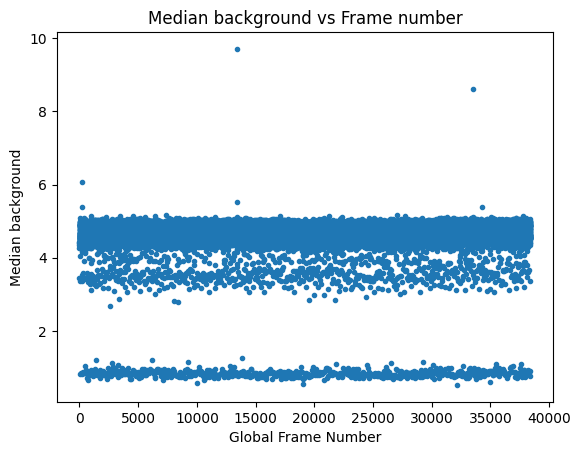

In [16]:
# Median value in each frame

for i in range(totframes):
    med                     = np.median(datacube[i, :, :])
    photometry[i, mbkg_col] = med
    datacube[i, :, :]      -= med # subtract median

# Background vs frame number
plt.figure()
plt.scatter(np.arange(totframes), photometry[:, mbkg_col], marker='.')
plt.xlabel("Global Frame Number")
plt.ylabel("Median background")
plt.title("Median background vs Frame number")
plt.show()

In [17]:
print('Problem 8 \n')

Problem 8 



In [18]:
# Sigma-rejection routine

def sigma_reject(data, sigma, iters):
    """
    Sigma-rejection

    Parameters
    data : np.array
        data array
    sigma : int or float
        sigma
    iters : int or float
        number of iterations
    
    Returns
        Boolean array where True = good pixel, False = bad pixel.
    """
    clipped   = sigma_clip(data, sigma=sigma, maxiters=iters, masked=True)
    # With masked = True, a boolean mask is returned where the clipped values are True
    # So just reverse where True values are not clipped and False are clipped
    bad_mask  = np.ma.getmaskarray(clipped)
    good_mask = ~bad_mask
    return np.asarray(good_mask)

In [19]:
print('Problem 9 \n')

Problem 9 



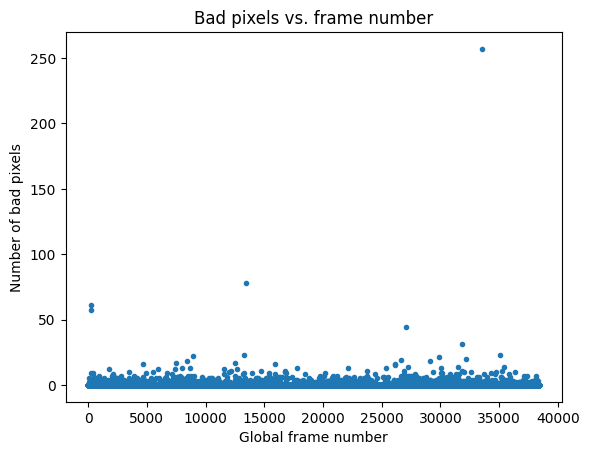

In [20]:
# Find bad pixels

# First loop steps by jumps of 64
for f0 in range(0, totframes, nf):
    f63 = f0 + nf # end index (exclusive) for this block
    # Second and third loops over y and x
    for y in range(ny):
        for x in range(nx):
            # Extract each set of 64 pixels (1 from each frame) at same y, x
            extract = datacube[f0:f63, y, x]

            # Sigma reject on each set
            good = sigma_reject(extract, clip_sig, max_iter)

            # Insert resulting boolean into mak array
            # Keeps good pixels true from good
            # Makes false pixels bad from sigma_clip
            mask[f0:f63, y, x] &= good

# Bad pixels vs frame number
bad_per_frame = np.sum(~mask, axis=(1, 2))

plt.figure()
plt.scatter(np.arange(totframes), bad_per_frame, marker='.')
plt.xlabel("Global frame number")
plt.ylabel("Number of bad pixels")
plt.title("Bad pixels vs. frame number")
plt.show()

In [21]:
print('Problem 10 \n')

Problem 10 



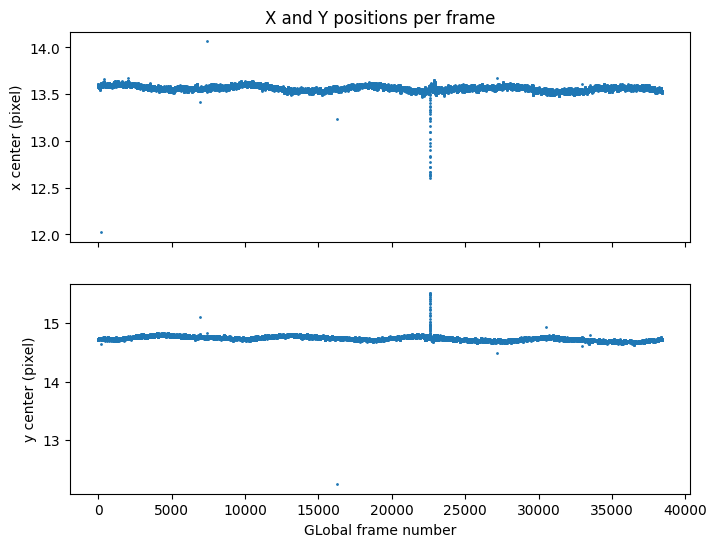

In [22]:
# Approximate location of center of star routine

def fitcenter(frame, yguess, xguess, subz):
    """
    Fit 2D Gaussian around guess

    Parameters
    
    center : (yguess, xguess)
    """

    # Subarray
    yg, xg = int(yguess), int(xguess)

    ytop = yg + subz + 1
    ybot = yg - subz
    xtop = xg + subz + 1
    xbot = xg - subz

    sub = frame[ybot:ytop, xbot:xtop].copy()
    sub -= np.median(sub) # median sub

    # Fitting relative to subarr (width tuple) (center tuple) (height)
    guess = ((3.0, 3.0), (yg - ybot, xg - xbot), np.max(sub))

    # Gaussian fit
    fw, fc, fh, fe = g.fitgaussian(sub, guess=guess)

    sigma_avg = float((fw[0] + fw[1]) / 2.0)

    # Fitting back to original coords
    cy, cx = float(fc[0] + ybot), float(fc[1] + xbot)

    return cy, cx, sigma_avg
    
# For the first frame, viually its about y, x = 15, 14
frame0 = datacube[0, :, :]
y0, x0 = 14.7, 13.5
cy0, cx0, sigma = fitcenter(frame0, y0, x0, ssize)
photometry[0, ycen_col] = cy0
photometry[0, xcen_col] = cx0

# Looping over all imtages, using previous fitted position as guess
for i in range(1, totframes):
    framei = datacube[i, :, :]
    yi, xi = photometry[i-1, ycen_col], photometry[i-1, xcen_col]
    cyi, cxi, sigma_i       = fitcenter(framei, yi, xi, ssize)
    photometry[i, ycen_col] = cyi
    photometry[i, xcen_col] = cxi
    photometry[i, widt_col] = sigma_i

# Plot x and y position vs the frame number
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

ax1.plot(photometry[:, xcen_col], '.', ms=2)
ax1.set_ylabel('x center (pixel)')
ax1.set_title('X and Y positions per frame')
ax2.plot(photometry[:, ycen_col], '.', ms=2)
ax2.set_ylabel('y center (pixel)')
ax2.set_xlabel('GLobal frame number')
plt.show()

In [23]:
print('Problem 11 \n')

Problem 11 



In [24]:
# Median image from whole dataset
median_image = np.median(datacube, axis=0)

# For offset from main star
ygstar, xgstar = 14.7, 13.6   # main star
cystar, cxstar, _ = fitcenter(median_image, ygstar, xgstar, ssize)

ygfaint, xgfaint = 6, 9       # faint star
cyfaint, cxfaint, _ = fitcenter(median_image, ygfaint, xgfaint, ssize)

# Offset in median image
yoff = cyfaint - cystar
xoff = cxfaint - cxstar

print(f"Companion star is offset by a change in y = {yoff} pixels, and a change in x = {xoff} pixels")

# Mask the companion star in each frame
r_mask = 2  # radius of disk to mask around the companion
yy, xx = np.indices((ny, nx)) # coordinate grid

for i in range(totframes):
    # Star center for this frame
    cy = photometry[i, ycen_col]
    cx = photometry[i, xcen_col]

    # Apply offset for companion center
    cy_comp = cy + yoff
    cx_comp = cx + xoff

    # Mask disk to remove companion star
    dist = (yy - cy_comp)**2 + (xx - cx_comp)**2

    # Mark pixels within radius as bad (False)
    mask[i, dist <= r_mask**2] = False

Companion star is offset by a change in y = -8.533992268044084 pixels, and a change in x = -4.1918147351446216 pixels


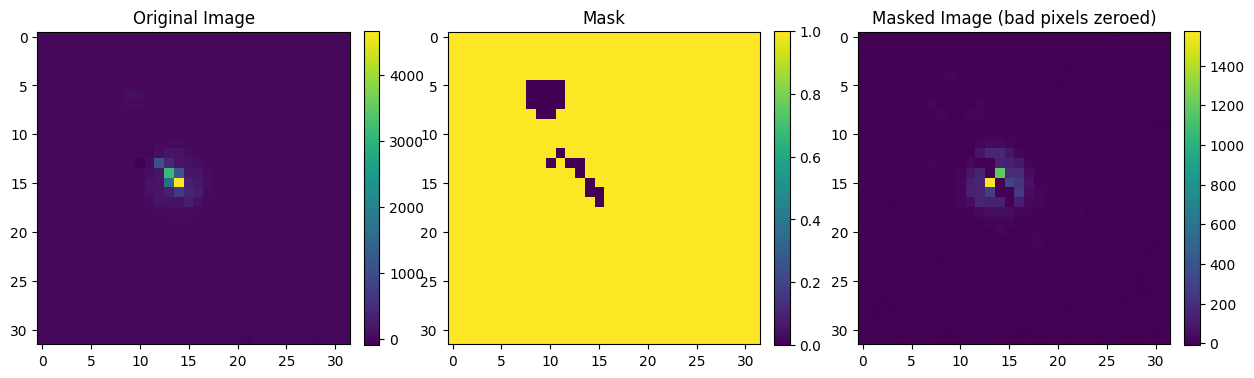

In [25]:
# This should have a companion and bad pixels
test = 410

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
im0 = axes[0].imshow(datacube[test])
axes[0].set_title('Original Image')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Bad pixel mask (should have bad pixels and companion as bad)
im1 = axes[1].imshow(mask[test])
axes[1].set_title('Mask')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Masked image
im2 = axes[2].imshow(datacube[test] * mask[test])
axes[2].set_title('Masked Image (bad pixels zeroed)')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

In [26]:
print('Problem 12 \n')

Problem 12 



In [27]:
# Aperture photometry using HW 10

def aperture_photometry(data, mask, photrad, skyin, skyout, center):
    """
    Parameters
    ----------
    Returns
    -------
    arr : array
        [flux, average sky, number of bad pixels]
    """
    # No need for a subimage

    # a) use disk to make mask of sky annulus
    skymask = d.disk( skyout, center, data.shape)^d.disk( skyin, center, data.shape ) 

    # b) apply bad-pixel mask to sky annulus (only good sky pixels)
    good_sky = skymask * mask

    # c) average sky level using only good sky pixels
    skyavg = np.sum( good_sky * data ) / np.sum( good_sky )

    # d) subtract sky from image
    data_sky_sub = data - skyavg

    # e) aperture mask (do NOT apply bad-pixel mask here)
    apmask = d.disk(photrad, center, data.shape)
    good_ap = apmask * mask
    bad_ap  = apmask * ~mask

    # f) total stellar flux in the aperture (sky already subtracted)
    flux = np.sum( good_ap * data_sky_sub )

    # g) number of bad pixels in the aperture, ~mask is bad pixels
    nbadapt = np.sum(bad_ap)

    return np.array([flux, skyavg, nbadapt])

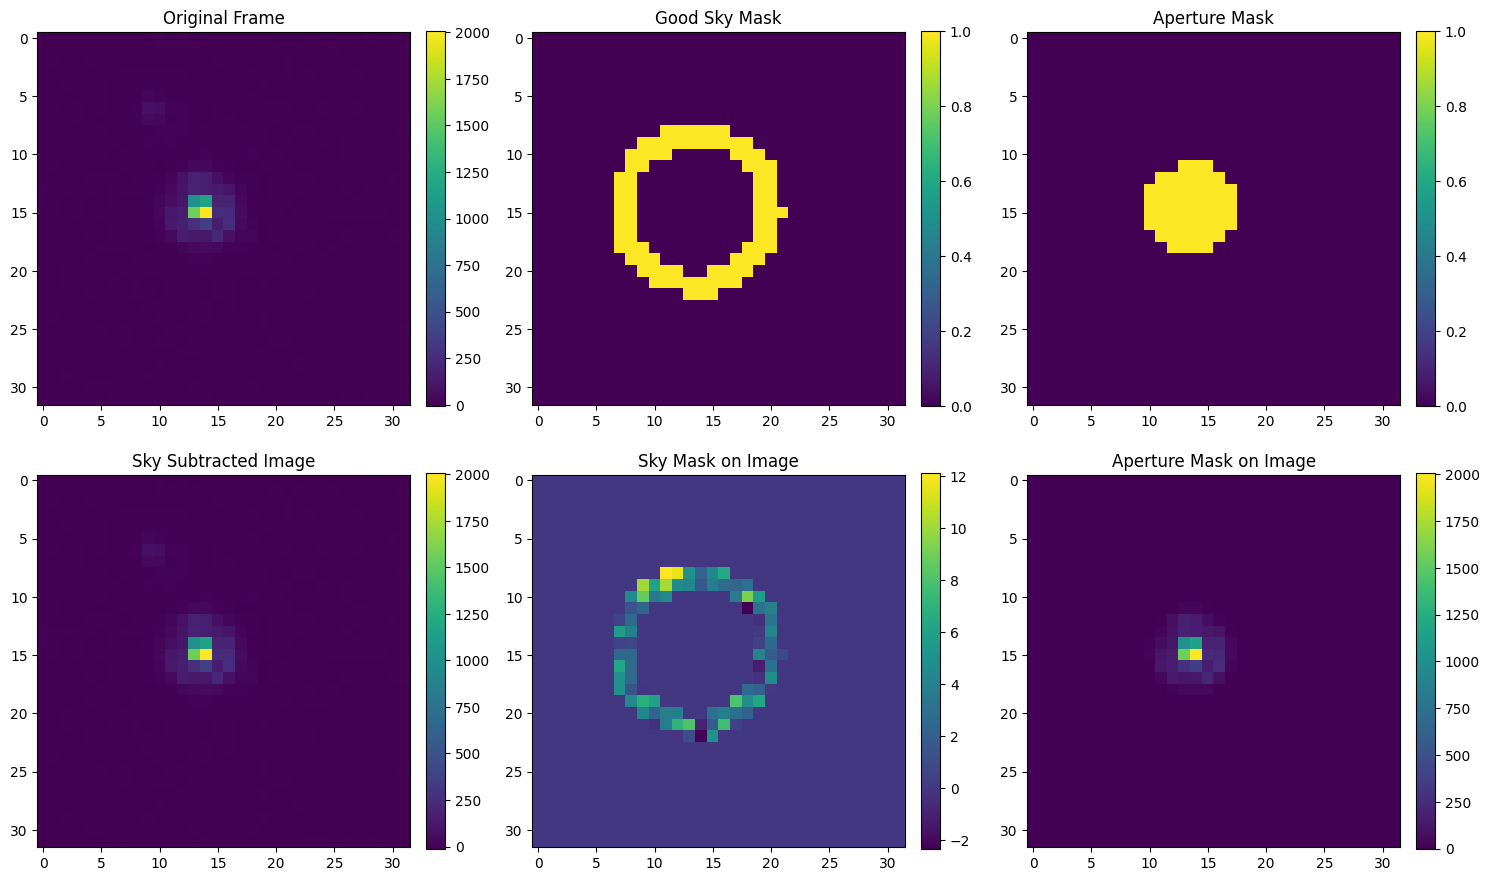

In [64]:
# Testing to see if output looks good
test = 900 # 410 is one with bad pixels

sigmatest   = photometry[test, widt_col]
photradtest = 6.0 * sigmatest 
skyintest   = 8.0 * sigmatest
skyouttest  = 11.0 * sigmatest

cy = photometry[test, ycen_col]
cx = photometry[test, xcen_col]

center = (cy, cx)

skymask = d.disk(skyouttest, center, datacube[test].shape)^d.disk( skyintest, center, datacube[test].shape ) 

good_sky = skymask * mask[test]

skyavg = np.sum( good_sky * datacube[test] ) / np.sum( good_sky )

data_sky_sub = datacube[test] - skyavg

apmask = d.disk(photradtest, center, datacube[test].shape)
good_ap = apmask * mask[test]


fig, axes = plt.subplots(2, 3, figsize=(15, 9))
(ax0, ax1, ax2), (ax3, ax4, ax5) = axes

# Original frame
im0 = ax0.imshow(datacube[test])
ax0.set_title('Original Frame')
fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

# Good-sky mask
im1 = ax1.imshow(good_sky)
ax1.set_title('Good Sky Mask')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Aperture mask
im2 = ax2.imshow(good_ap)
ax2.set_title('Aperture Mask')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# Sky-subtracted image
im3 = ax3.imshow(data_sky_sub)
ax3.set_title('Sky Subtracted Image')
fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

# Sky-mask * original
im4 = ax4.imshow(good_sky * datacube[test])
ax4.set_title('Sky Mask on Image')
fig.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

# Aperture mask * sky-subtracted frame
im5 = ax5.imshow(good_ap * data_sky_sub)
ax5.set_title('Aperture Mask on Image')
fig.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [29]:
print('Problem 13 \n')

Problem 13 



In [ ]:
# Loop over all frames and update table
# Store aperture counts(flux), average sky, and number of bad pixels

# Determining from average width
sigall   = np.mean(photometry[:, widt_col])
photrad  = 6.0 * sigall
skyin    = 8.0 * sigall
skyout   = 11.0 * sigall

# Loop
for i in range(totframes):

    frame = datacube[i]
    fmask  = mask[i]

    cy = photometry[i, ycen_col]
    cx = photometry[i, xcen_col]

    photarr = aperture_photometry(frame, fmask, photrad, skyin, skyout, (cy, cx))
    
    photometry[i, flux_col] = photarr[0]
    photometry[i, asky_col] = photarr[1]
    photometry[i, nbad_col] = photarr[2]

In [31]:
print('Problem 14 \n')

Problem 14 



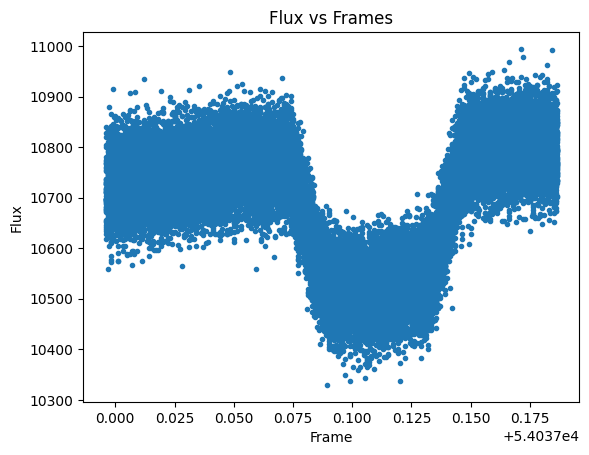

In [71]:
# Check photometry

# Good frames with no bad pixels in them
# If good frame, then no bad pixels in bad_col
goodframes = photometry[:, nbad_col] == 0

good_flux = photometry[goodframes, flux_col]
frames    = sorted(np.arange(totframes)[goodframes])
frames2   = photometry[goodframes, glof_col]
frames3   = photometry[goodframes, date_col]


plt.figure()
plt.scatter(frames3, good_flux, marker='.')
plt.xlabel('Frame')
plt.ylabel('Flux')
plt.title('Flux vs Frames')
plt.show()

In [62]:
# There doesn't appear to be an obvious transit, but there are distinct outliers

goodframes = photometry[:, nbad_col] == 0

good_flux = photometry[goodframes, flux_col]
frames    = np.arange(totframes)[goodframes]

# For frames with a high background
good_sky  = photometry[goodframes, asky_col] # good sky values
sky_med = np.median(good_sky)
sky_std = np.std(good_sky)
high_sky = (photometry[:, asky_col] > sky_med + 5 * sky_std) & goodframes
# Set bad_col to -1
photometry[high_sky, nbad_col] = -1  # very high background

# FOr frames with large star motion
y_good    = photometry[goodframes, ycen_col]
x_good    = photometry[goodframes, xcen_col]

y_med = np.median(photometry[goodframes, ycen_col])
x_med = np.median(photometry[goodframes, xcen_col])

dy = photometry[:, ycen_col] - y_med
dx = photometry[:, xcen_col] - x_med
dr = np.sqrt(dx**2 + dy**2) # error propagation

large_motion = (dr > 0.5) & goodframes
photometry[large_motion, nbad_col] = -1

# Recompute good frames after
new_good     = photometry[:, nbad_col] == 0
nframes_good = np.arange(totframes)[new_good]
nflux_good   = photometry[new_good, flux_col]
nsky_good    = photometry[new_good, asky_col]
ny_good      = photometry[new_good, ycen_col]
nx_good      = photometry[new_good, xcen_col]
nbad_good    = photometry[new_good, nbad_col]

# All frames
frames_all   = np.arange(totframes)
flux_all     = photometry[:, flux_col]
sky_all      = photometry[:, asky_col]
bad_all      = photometry[:, nbad_col]
y_all        = photometry[:, ycen_col]
x_all        = photometry[:, xcen_col]

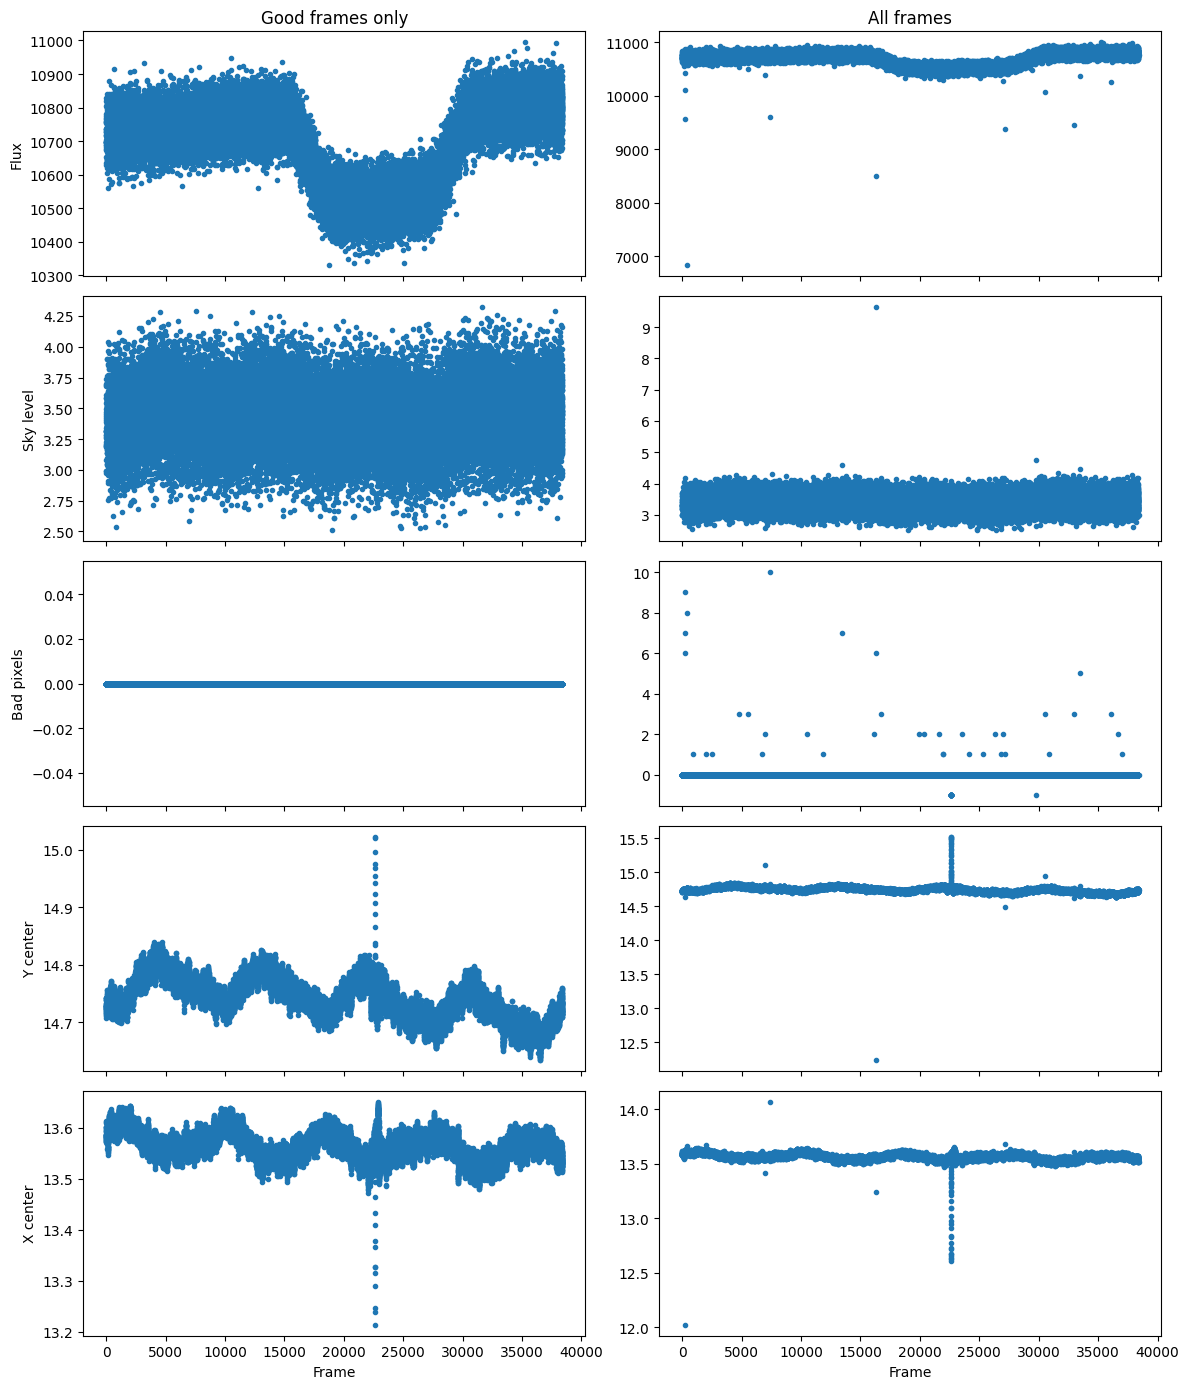

In [63]:
# Plots
fig, axes = plt.subplots(5, 2, figsize=(12, 14), sharex='col')

# Flux
axes[0, 0].plot(nframes_good, nflux_good, 'o', ms=3)
axes[0, 0].set_ylabel('Flux')
axes[0, 0].set_title('Good frames only')

axes[0, 1].plot(frames_all, flux_all, 'o', ms=3)
axes[0, 1].set_title('All frames')

# Average sky
axes[1, 0].plot(nframes_good, nsky_good, 'o', ms=3)
axes[1, 0].set_ylabel('Sky level')

axes[1, 1].plot(frames_all, sky_all, 'o', ms=3)

# Bad pixels in aperture
axes[2, 0].plot(nframes_good, nbad_good, 'o', ms=3)
axes[2, 0].set_ylabel('Bad pixels')

axes[2, 1].plot(frames_all, bad_all, 'o', ms=3)

# Y center
axes[3, 0].plot(nframes_good, ny_good, 'o', ms=3)
axes[3, 0].set_ylabel('Y center')

axes[3, 1].plot(frames_all, y_all, 'o', ms=3)

# X center
axes[4, 0].plot(nframes_good, nx_good, 'o', ms=3)
axes[4, 0].set_ylabel('X center')
axes[4, 0].set_xlabel("Frame")

axes[4, 1].plot(frames_all, x_all, 'o', ms=3)
axes[4, 1].set_xlabel('Frame')

plt.tight_layout()
plt.show()

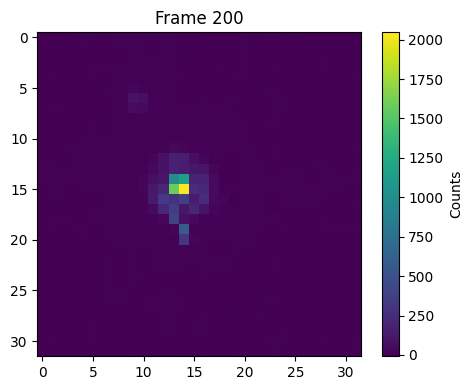

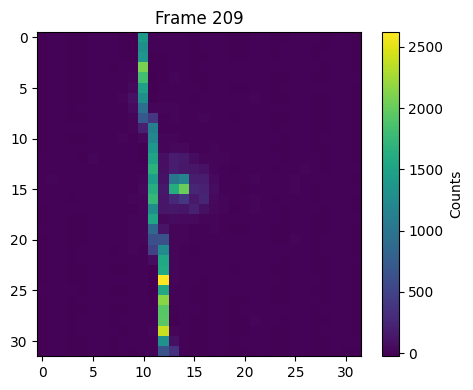

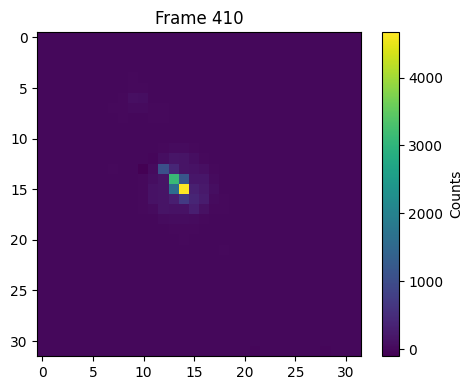

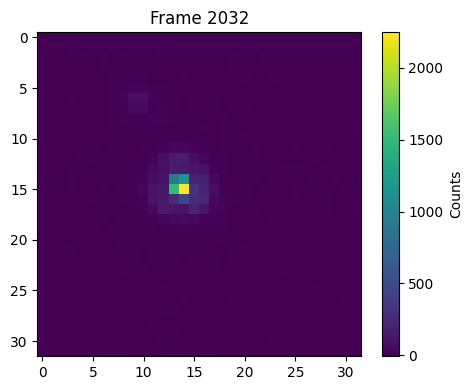

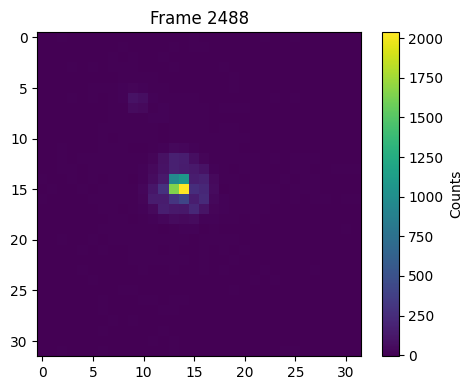

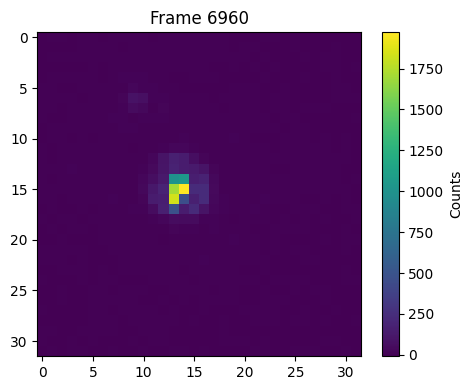

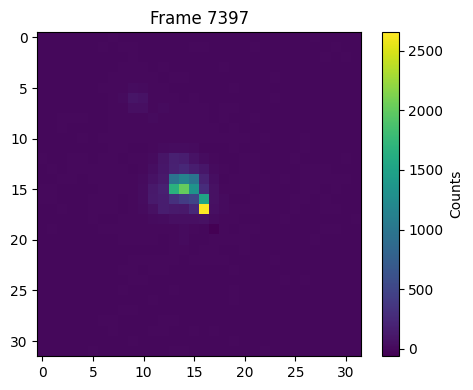

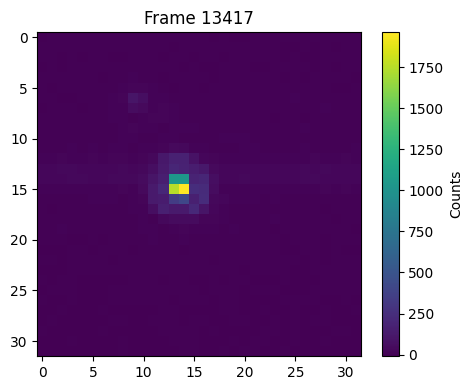

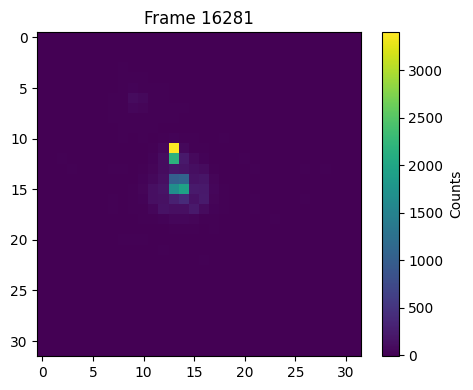

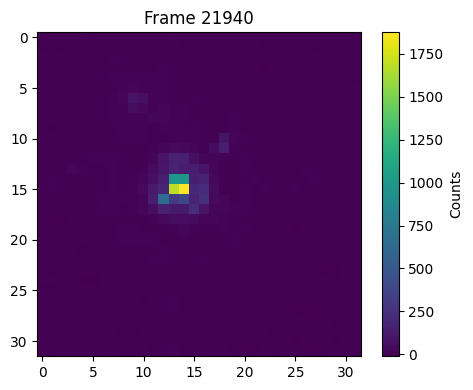

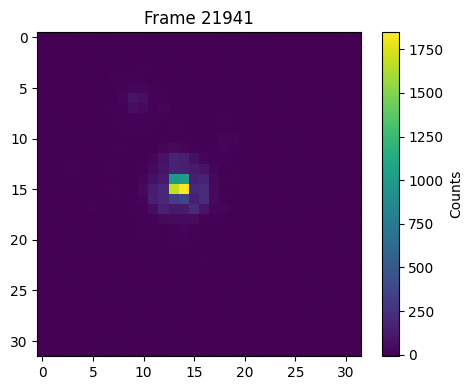

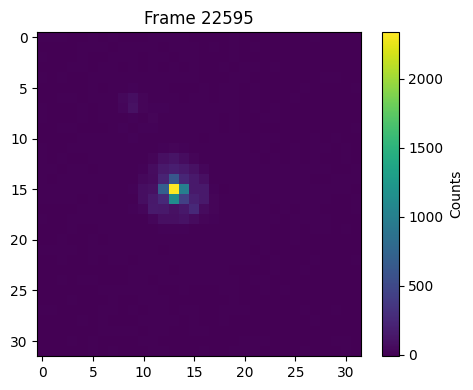

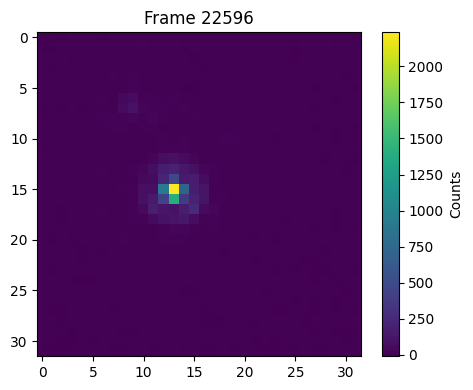

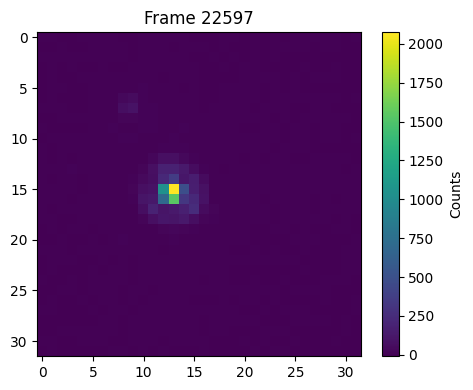

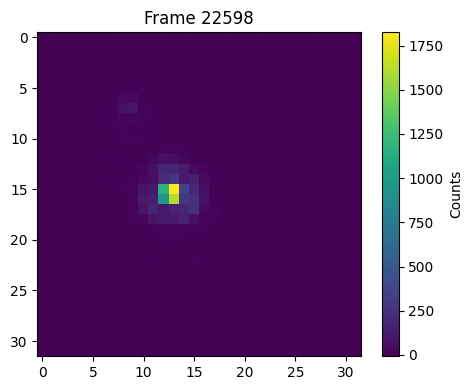

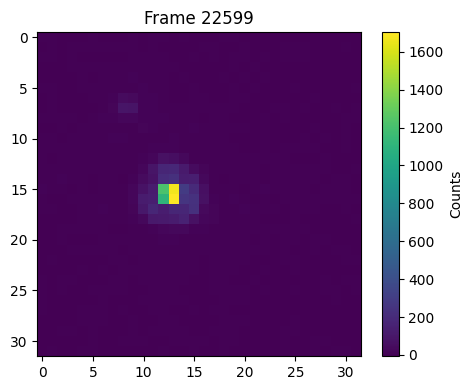

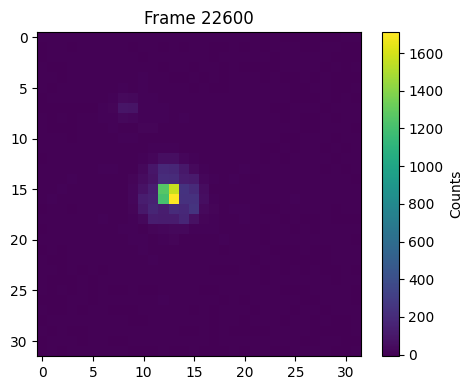

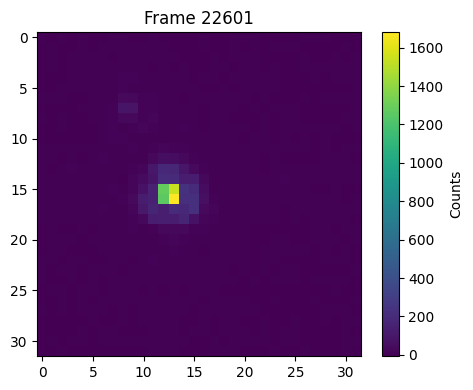

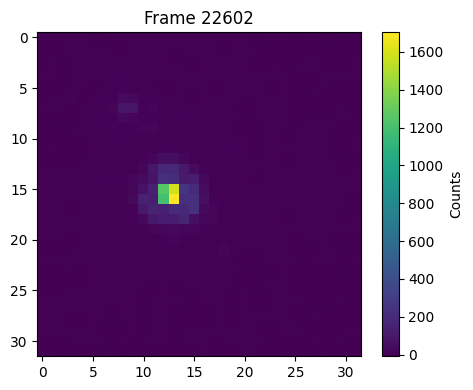

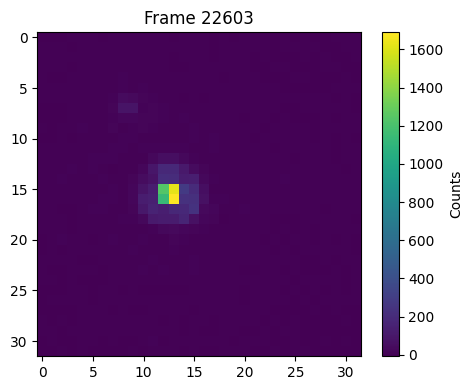

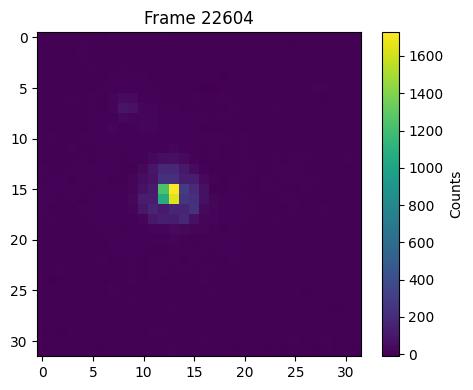

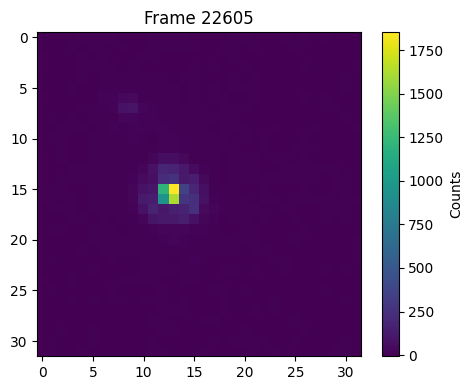

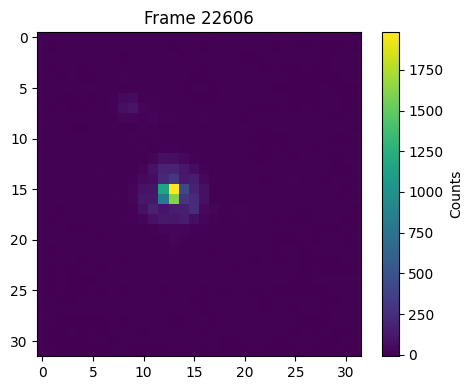

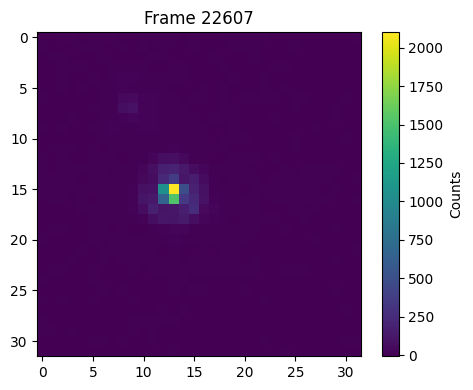

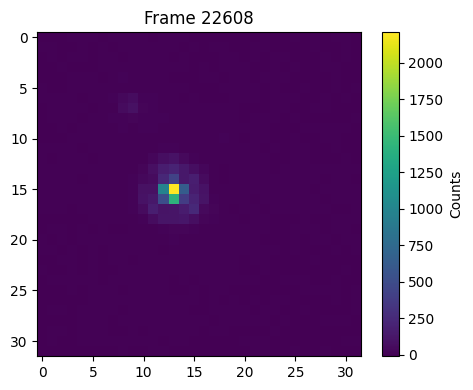

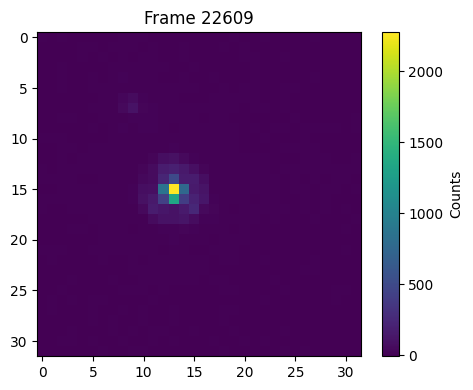

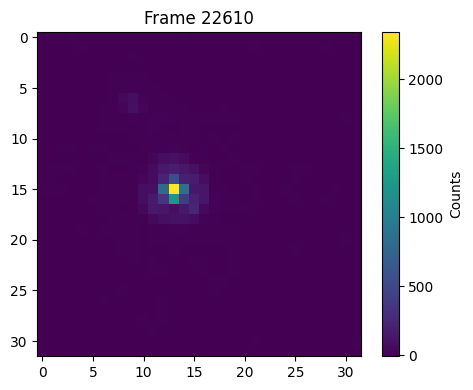

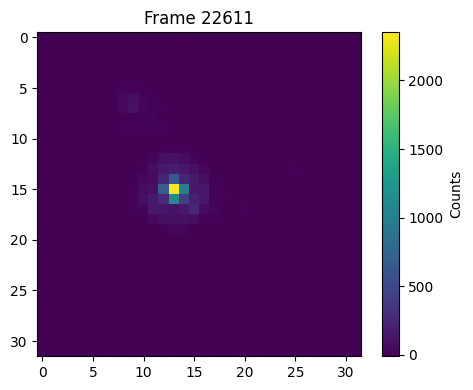

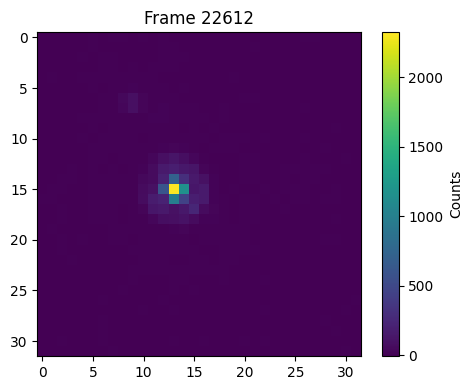

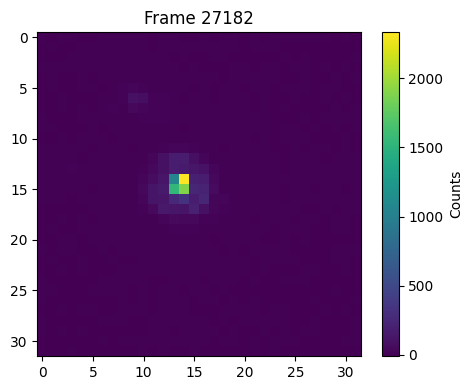

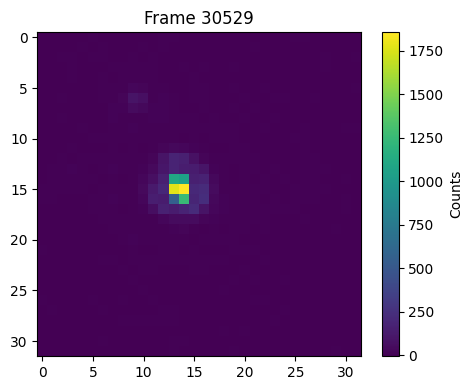

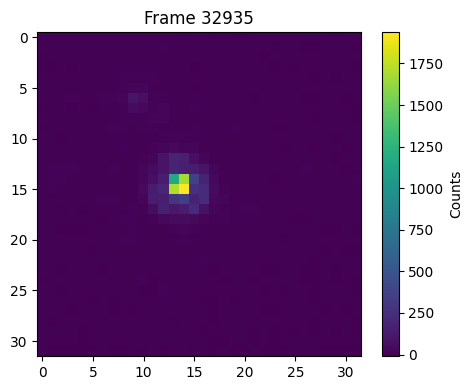

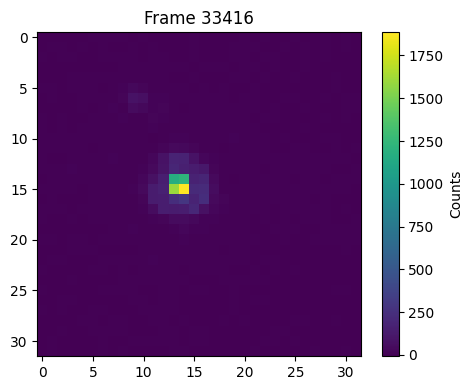

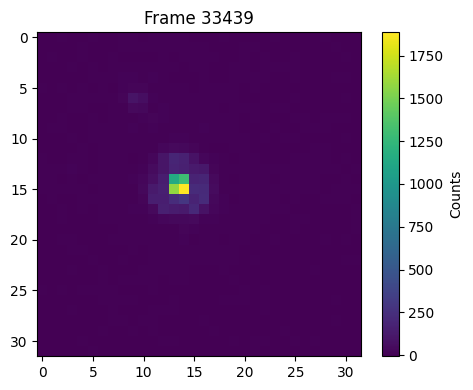

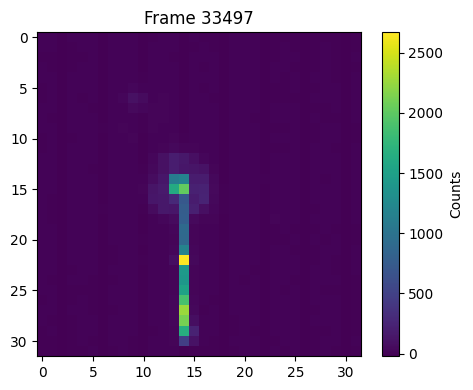

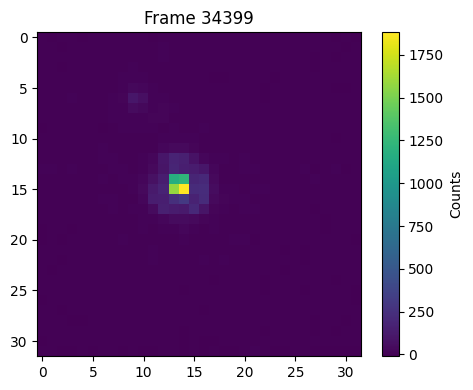

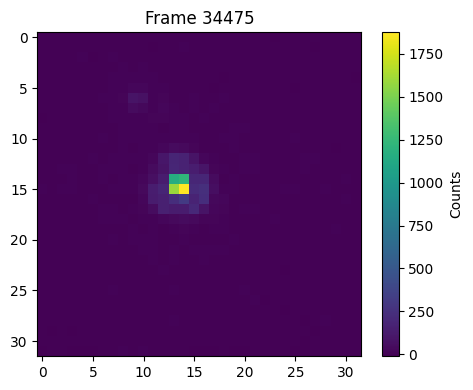

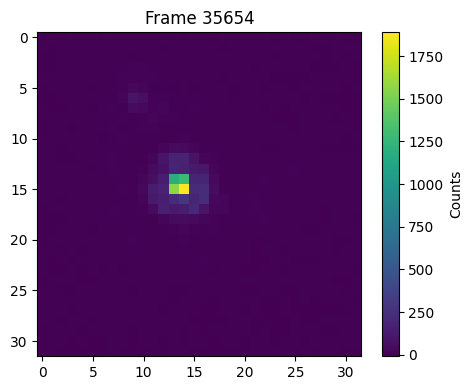

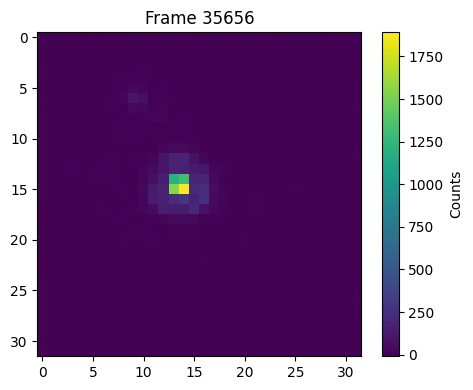

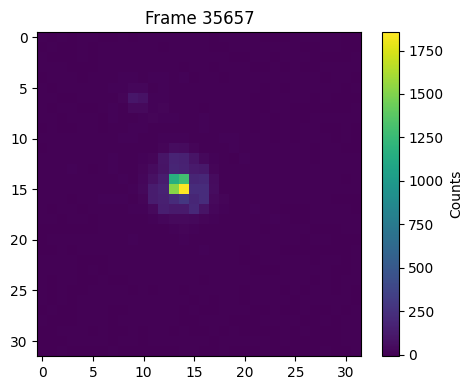

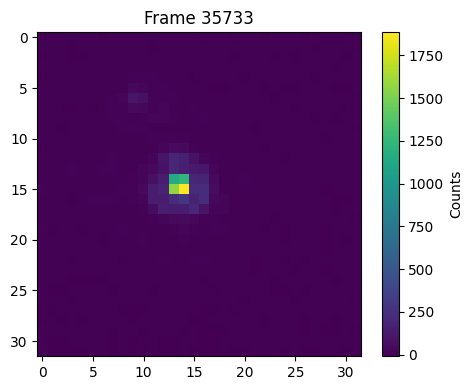

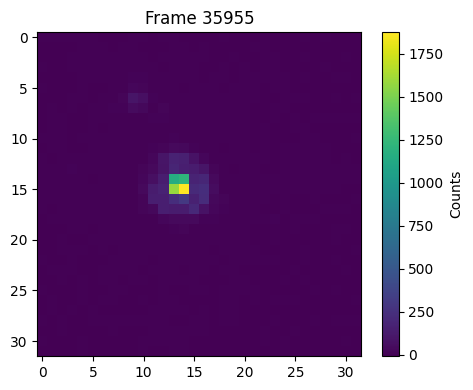

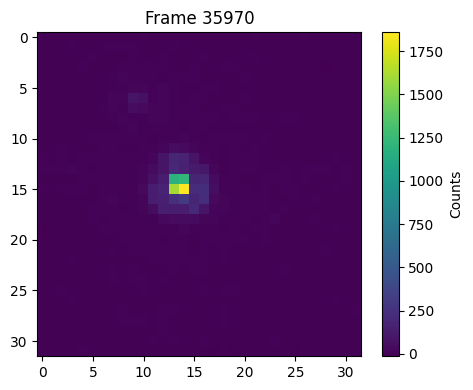

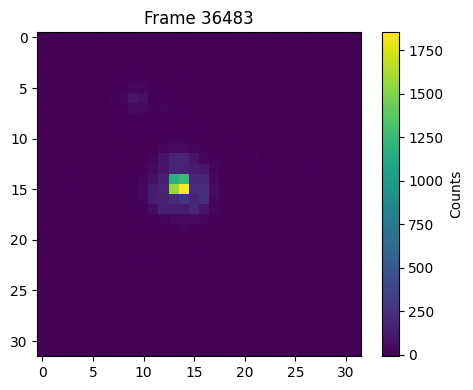

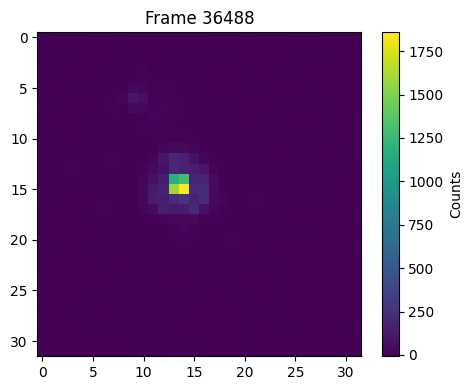

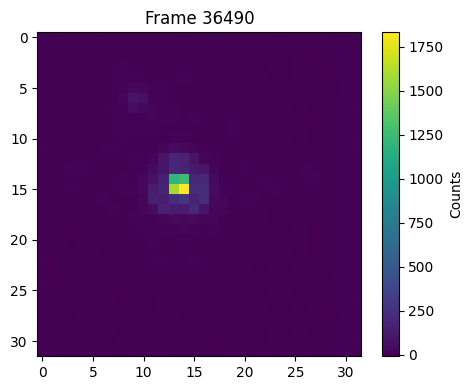

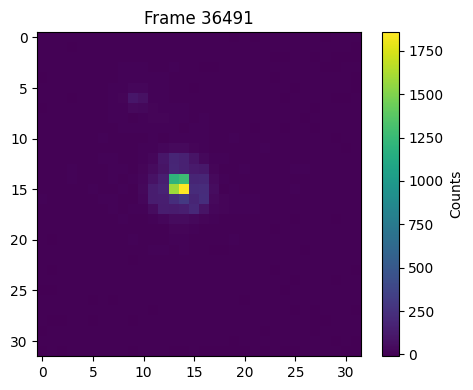

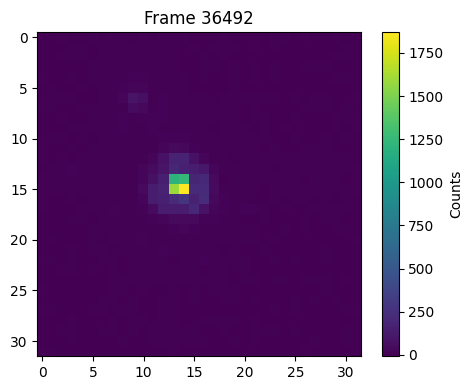

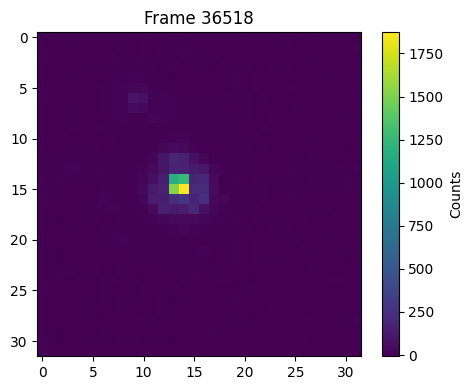

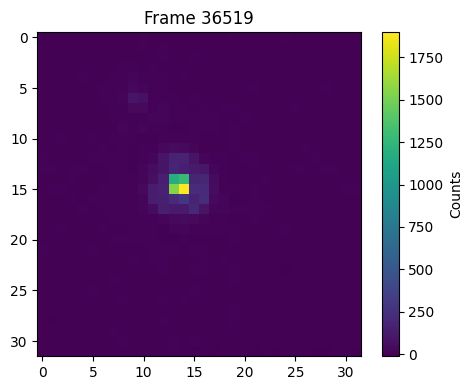

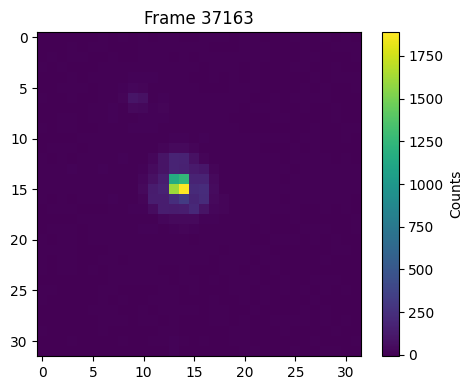

In [35]:
# Got RID OF THE OUTLIERS 

# Frames with at least one bad pixel in aperture
bad = photometry[:, nbad_col] != 0
bad_frames = np.arange(totframes)[bad]

for i in bad_frames:
    frame = datacube[i]
    plt.figure(figsize=(5, 4))
    plt.imshow(frame)
    plt.title(f"Frame {i}")
    plt.colorbar(label="Counts")
    plt.tight_layout()
    plt.show()

In [36]:
print('Problem 15 \n')

Problem 15 



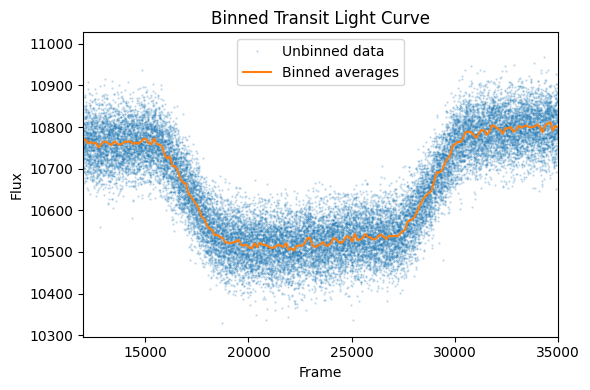

In [70]:
# Bin the data

# Use only good frames (no bad pixels and not flagged -1)
frames = nframes_good          # global frame numbers of good data
flux   = nflux_good            # corresponding fluxes

# Choose number of bins (adjust as desired)
N_bins = 300

# Define bin edges using frame numbers
bin_edges   = np.linspace(frames.min(), frames.max(), N_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Bin-average the flux
binned_flux = np.full(N_bins, np.nan)
bin_index   = np.digitize(frames, bin_edges) - 1  # bin indices 0..N_bins-1

for k in range(N_bins):
    in_bin = bin_index == k
    if np.any(in_bin):
        binned_flux[k] = np.mean(flux[in_bin])

# Remove empty bins
valid = ~np.isnan(binned_flux)
bin_centers = bin_centers[valid]
binned_flux = binned_flux[valid]

# Make a publication-ready plot and zoom in
plt.figure(figsize=(6, 4))
plt.plot(frames, flux, ".", ms=1, alpha=0.3, label="Unbinned data")
plt.plot(bin_centers, binned_flux, "-", lw=1.5, label="Binned averages")

# Zoom in on the transit region and flux range
plt.xlim(12000, 35000)

plt.xlabel("Frame")
plt.ylabel("Flux")
plt.title("Binned Transit Light Curve")
plt.legend()
plt.tight_layout()

# Save as PDF
plt.show()


In [38]:
print('Problem 16 \n')

Problem 16 



In [39]:
# Four frames of transit

# a) first contact

# b) second contact

# c) third contact

# d) fourth contact


In [40]:
print('Problem 17 \n')

Problem 17 



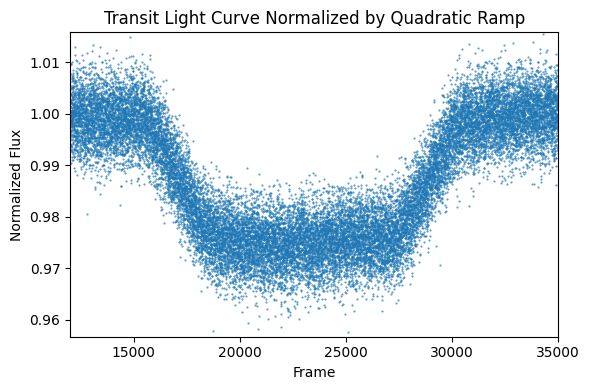

In [73]:
# Fit a parabola

# Frame numbers and raw flux for all frames
frames_all = np.arange(totframes)              # 0 .. 38399
flux_all   = photometry[:, flux_col]          # aperture photometry for all frames

# Good-frame mask (no bad pixels and not flagged -1)
good = photometry[:, nbad_col] == 0

# Good frames and flux
nframes_good = frames_all[good]
nflux_good   = flux_all[good]

# OUT-OF-TRANSIT selection among good frames
# Transit is between frames 12000 and 35000
out_of_transit = (nframes_good < 12000) | (nframes_good > 35000)

t_fit = nframes_good[out_of_transit]
f_fit = nflux_good[out_of_transit]

# Fit a quadratic (parabola) to out-of-transit data
# f(t) = a t^2 + b t + c
coef = np.polyfit(t_fit, f_fit, 2)

# Evaluate ramp model at ALL frames
ramp_model = np.polyval(coef, frames_all)

# Normalize all fluxes by ramp model
flux_norm_all = flux_all / ramp_model

# Normalized flux for good frames only
flux_norm_good = flux_norm_all[good]

# Make a publication-ready plot (zoomed around transit)
plt.figure(figsize=(6, 4))
plt.plot(nframes_good, flux_norm_good, ".", ms=1, alpha=0.8)

plt.xlabel("Frame")
plt.ylabel("Normalized Flux")
plt.title("Transit Light Curve Normalized by Quadratic Ramp")

# Zoom in on the transit region
plt.xlim(12000, 35000)

# Center y-limits around median in the transit region
in_transit_good = (nframes_good >= 12000) & (nframes_good <= 35000)
median_norm = np.median(flux_norm_good[in_transit_good])
plt.ylim(median_norm * 0.97, median_norm * 1.03)

plt.tight_layout()
#plt.savefig("problem17_normalized_ramp.pdf", format="pdf")
plt.show()

In [42]:
print('Problem 18 \n')

Problem 18 



In [74]:
# Flat run of normalized frames for S/N

# Choose a flat region after the transit, e.g., 36000–37000
flat_region = (nframes_good >= 36000) & (nframes_good <= 37000)

flat_frames = nframes_good[flat_region]
flat_flux   = flux_norm_good[flat_region]

# Ensure at least 100 points
print("Number of points in region:", len(flat_flux))

# Standard deviation of normalized flux
std_flat = np.std(flat_flux)

# Since normalized flux is ~1, S/N ≈ 1 / std
SN_per_frame = 1.0 / std_flat

print("Standard deviation in flat region:", std_flat)
print("S/N per frame:", SN_per_frame)

Number of points in region: 999
Standard deviation in flat region: 0.004638031261031553
S/N per frame: 215.60872355517245


In [44]:
print('Problem 19 \n')

Problem 19 



In [75]:
# -------------------------------------------------------------------
# Assumptions / Inputs from previous parts:
# - nframes_good: 1D array of frame numbers for *good* frames only
# - flux_norm_good: 1D array of normalized flux for good frames
#                   (each point ≈ 1 outside transit, ≈ 1 - depth in transit)
# - std_flat: per-frame uncertainty in normalized flux, σ_frame,
#             measured from a flat region in Q18
# - Transit is between frames 12000 and 35000.
#   To avoid ingress/egress (when limb cuts planet), we use a stricter
#   in-transit window [15000, 32000].
# -------------------------------------------------------------------

# Good out-of-transit frames: before 12000 or after 35000
good_out = (nframes_good < 12000) | (nframes_good > 35000)

# Good *strictly* in-transit frames (avoiding ingress/egress)
good_in_strict = (nframes_good >= 15000) & (nframes_good <= 32000)

# Extract flux subsets
F_out_samples = flux_norm_good[good_out]
F_in_samples  = flux_norm_good[good_in_strict]

N_out = F_out_samples.size
N_in  = F_in_samples.size

# -------------------------------------------------------------------
# Averages of normalized flux:
#   F_out = <F>_out, F_in = <F>_in
#   normalized so that F_out ≈ 1
# -------------------------------------------------------------------
F_out = np.mean(F_out_samples)
F_in  = np.mean(F_in_samples)

# -------------------------------------------------------------------
# Per-frame uncertainty σ_frame from Q18:
#   σ_frame = std_flat
#
# Standard error of the mean:
#   σ_out = σ_frame / sqrt(N_out)
#   σ_in  = σ_frame / sqrt(N_in)
# -------------------------------------------------------------------
sigma_frame = std_flat
sigma_out = sigma_frame / np.sqrt(N_out)
sigma_in  = sigma_frame / np.sqrt(N_in)

# -------------------------------------------------------------------
# Transit depth δ from normalized flux:
# We model the normalized light curve as:
#   F_norm(t) = F(t) / F_out
#
# In transit, the flux is reduced by the planet:
#   F_in ≈ F_out * (1 - δ)
#   => F_in / F_out ≈ 1 - δ
#   => δ = 1 - F_in / F_out
#
# For small planets and no limb darkening, the depth δ is:
#   δ ≈ (Rp^2 / Rs^2)
# so:
#   Rp^2 / Rs^2 ≈ δ
# -------------------------------------------------------------------
depth = 1.0 - (F_in / F_out)      # δ = 1 - F_in/F_out
area_ratio = depth                # Rp^2 / Rs^2 ≈ δ

# -------------------------------------------------------------------
# Uncertainty propagation for δ:
#
# Let:
#   x = F_in, y = F_out, δ = 1 - x / y
#
# Then:
#   δ(x, y) = 1 - x / y
#
# Partial derivatives:
#   ∂δ/∂x = -1 / y
#   ∂δ/∂y =  x / y^2
#
# Assuming x and y are independent with uncertainties σ_in, σ_out:
#   σ_δ^2 = (∂δ/∂x)^2 σ_in^2 + (∂δ/∂y)^2 σ_out^2
#          = (1 / y^2) σ_in^2 + (x^2 / y^4) σ_out^2
# -------------------------------------------------------------------
x = F_in
y = F_out

sigma_depth_sq = (1.0 / y**2) * sigma_in**2 + (x**2 / y**4) * sigma_out**2
sigma_depth = np.sqrt(sigma_depth_sq)

# Same uncertainty for area ratio:
sigma_area_ratio = sigma_depth

# -------------------------------------------------------------------
# Print required values
# -------------------------------------------------------------------
print("Number of good out-of-transit frames (N_out):", N_out)
print("Number of good in-transit frames (N_in, strict):", N_in)
print("Per-frame uncertainty (sigma_frame):", sigma_frame)
print("Out-of-transit mean normalized flux (F_out):", F_out)
print("In-transit mean normalized flux (F_in):", F_in)
print("Std error of F_out (sigma_out):", sigma_out)
print("Std error of F_in (sigma_in):", sigma_in)
print("Transit depth δ = Rp^2/Rs^2:", depth)
print("Uncertainty in depth δ (sigma_depth):", sigma_depth)
print("Planet/star area ratio Rp^2/Rs^2:", area_ratio)
print("Uncertainty in Rp^2/Rs^2:", sigma_area_ratio)

Number of good out-of-transit frames (N_out): 15382
Number of good in-transit frames (N_in, strict): 16965
Per-frame uncertainty (sigma_frame): 0.004638031261031553
Out-of-transit mean normalized flux (F_out): 1.0000000001712983
In-transit mean normalized flux (F_in): 0.9825488665861328
Std error of F_out (sigma_out): 3.739618228170167e-05
Std error of F_in (sigma_in): 3.5608750897549023e-05
Transit depth δ = Rp^2/Rs^2: 0.017451133582176093
Uncertainty in depth δ (sigma_depth): 5.1167113992066715e-05
Planet/star area ratio Rp^2/Rs^2: 0.017451133582176093
Uncertainty in Rp^2/Rs^2: 5.1167113992066715e-05


In [46]:
print('Problem 20 \n')

Problem 20 



In [76]:
# Radius of the star

# --- Stellar radius of HD 189733 from Boyajian et al. (2015, MNRAS 447, 846–857) ---
R_star_Rsun        = 0.805   # R_* in units of R_sun
sigma_R_star_Rsun  = 0.016   # uncertainty in R_*

# --- From Question 19 (already computed) ---
# area_ratio        = Rp^2 / Rs^2  = transit depth δ
# sigma_area_ratio  = uncertainty on δ
# Make sure these exist from Q19 before running this cell.

delta       = area_ratio
sigma_delta = sigma_area_ratio

# Planet radius in solar radii:
#   Rp = Rs * sqrt(δ)
Rp_Rsun = R_star_Rsun * np.sqrt(delta)

# Error propagation:
#   Rp = f(Rs, δ) = Rs * δ^(1/2)
#   ∂Rp/∂Rs = sqrt(δ)
#   ∂Rp/∂δ = Rs / (2 * sqrt(δ))
dRp_dRs = np.sqrt(delta)
dRp_dd  = R_star_Rsun / (2.0 * np.sqrt(delta))

sigma_Rp_Rsun = np.sqrt( (dRp_dRs**2) * (sigma_R_star_Rsun**2) +
                         (dRp_dd**2)  * (sigma_delta**2) )

# Convert to Jupiter radii:
#   R_sun / R_Jup ≈ 9.731
Rsun_over_Rjup = 9.73115873104683

Rp_Rjup        = Rp_Rsun * Rsun_over_Rjup
sigma_Rp_Rjup  = sigma_Rp_Rsun * Rsun_over_Rjup

# Print everything
print("Stellar radius R_*:", R_star_Rsun, "+/-", sigma_R_star_Rsun, "R_sun")
print("Area ratio Rp^2/Rs^2 (delta):", delta, "+/-", sigma_delta)
print("Planet radius R_p:", Rp_Rsun, "+/-", sigma_Rp_Rsun, "R_sun")
print("Planet radius R_p:", Rp_Rjup, "+/-", sigma_Rp_Rjup, "R_Jup")

Stellar radius R_*: 0.805 +/- 0.016 R_sun
Area ratio Rp^2/Rs^2 (delta): 0.017451133582176093 +/- 5.1167113992066715e-05
Planet radius R_p: 0.10634270468438191 +/- 0.0021193854959764887 R_sun
Planet radius R_p: 1.0348377391725576 +/- 0.020624076673625626 R_Jup
